In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported!")

Libraries imported!


In [21]:
nltk.download('vader_lexicon')
print("VADER ready!")

VADER ready!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\stsio\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [22]:
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
print(f"Total rows: {news_df.shape[0]:,}")
print(f"Columns: {news_df.columns.tolist()}")
news_df.head()

Total rows: 1,407,328
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [23]:
# Convert date to datetime
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# Drop rows with missing dates
news_df = news_df.dropna(subset=['date'])

# Extract date only
news_df['news_date'] = news_df['date'].dt.date

print(f"Rows after cleaning: {len(news_df):,}")
print(f"Date range: {news_df['date'].min()} to {news_df['date'].max()}")

# Apply VADER sentiment
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))['compound']

print("Applying sentiment to headlines...")
news_df['sentiment'] = news_df['headline'].apply(get_sentiment)
print("Done!")

# Keep only needed columns
news_df = news_df[['stock', 'news_date', 'sentiment']]
print("\nSample results:")
news_df.head(10)

Rows after cleaning: 55,987
Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
Applying sentiment to headlines...
Done!

Sample results:


,stock,news_date,sentiment
0,A,2020-06-05,0.000
1,A,2020-06-03,0.000
2,A,2020-05-26,0.000
3,A,2020-05-22,0.000
4,A,2020-05-22,0.296
5,A,2020-05-22,-0.128
6,A,2020-05-22,0.000
7,A,2020-05-22,0.296
8,A,2020-05-22,-0.128
9,A,2020-05-22,0.000


In [24]:
# Check unique stock symbols
unique_stocks = news_df['stock'].unique()
print(f"Number of unique stocks: {len(unique_stocks)}")
print("\nFirst 30 unique stock symbols:")
print(unique_stocks[:30])

# Check our target stocks
target_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
print("\n=== Target Stocks Availability ===")
for ticker in target_stocks:
    count = len(news_df[news_df['stock'] == ticker])
    print(f"{ticker}: {count} articles")

Number of unique stocks: 6204

First 30 unique stock symbols:
<StringArray>
[   'A',   'AA',  'AAC', 'AADR',  'AAL', 'AAMC', 'AAME',  'AAN', 'AAOI',
 'AAON',  'AAP', 'AAPL',  'AAU',  'AAV', 'AAVL', 'AAWW', 'AAXJ',   'AB',
 'ABAC', 'ABAX',  'ABB', 'ABBV',  'ABC', 'ABCB', 'ABCD', 'ABCO', 'ABCW',
 'ABDC', 'ABEV',  'ABG']
Length: 30, dtype: str

=== Target Stocks Availability ===
AAPL: 10 articles
AMZN: 10 articles
GOOG: 10 articles
META: 0 articles
NVDA: 10 articles


In [25]:
# Use only stocks that have news data
valid_stocks = ['AAPL', 'AMZN', 'GOOG', 'NVDA']
stock_data = {}
trading_days = {}

print("=== Loading Stock Data ===")
for ticker in valid_stocks:
    df = pd.read_csv(f'../data/raw/{ticker}.csv')
    df.columns = df.columns.str.lower()
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df.sort_values('date').reset_index(drop=True)
    df['daily_return'] = df['close'].pct_change() * 100
    
    stock_data[ticker] = df
    trading_days[ticker] = set(df['date'])
    
    print(f"{ticker}: {len(df)} rows, {df['date'].min()} to {df['date'].max()}")

print("\nAll stock data loaded!")

=== Loading Stock Data ===
AAPL: 3774 rows, 2009-01-02 to 2023-12-29
AMZN: 3774 rows, 2009-01-02 to 2023-12-29
GOOG: 3774 rows, 2009-01-02 to 2023-12-29
NVDA: 3774 rows, 2009-01-02 to 2023-12-29

All stock data loaded!


In [26]:
def align_to_trading_day(news_date, trading_days_set):
    """Align news date to next available trading day"""
    if news_date in trading_days_set:
        return news_date
    # Find next trading day
    next_day = news_date + timedelta(days=1)
    while next_day not in trading_days_set:
        next_day += timedelta(days=1)
    return next_day

print("Date alignment function created!")

Date alignment function created!


In [27]:
aligned_news = {}
daily_sentiment = {}
merged_data = {}

print("=== Processing Each Stock ===")
for ticker in valid_stocks:
    # Filter news for this stock
    stock_news = news_df[news_df['stock'] == ticker].copy()
    
    if len(stock_news) > 0:
        # Align dates to trading days
        stock_news['aligned_date'] = stock_news['news_date'].apply(
            lambda x: align_to_trading_day(x, trading_days[ticker])
        )
        aligned_news[ticker] = stock_news
        
        # Aggregate daily sentiment (average per day)
        daily_sentiment[ticker] = stock_news.groupby('aligned_date')['sentiment'].mean().reset_index()
        daily_sentiment[ticker].columns = ['date', 'avg_sentiment']
        
        # Merge with stock returns
        merged_data[ticker] = pd.merge(
            daily_sentiment[ticker], 
            stock_data[ticker][['date', 'daily_return']], 
            on='date', 
            how='inner'
        )
        
        print(f"{ticker}: {len(stock_news)} news articles → {len(merged_data[ticker])} matched trading days")
    else:
        print(f"{ticker}: No news articles found")

print("\nAll data processed!")

=== Processing Each Stock ===
AAPL: 10 news articles → 2 matched trading days
AMZN: 10 news articles → 2 matched trading days
GOOG: 10 news articles → 5 matched trading days
NVDA: 10 news articles → 5 matched trading days

All data processed!


In [28]:
for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        print(f"\n=== {ticker} ===")
        print(merged_data[ticker])


=== AAPL ===
         date  avg_sentiment  daily_return
0  2020-06-09        0.24690      3.157792
1  2020-06-10        0.19885      2.572771

=== AMZN ===
         date  avg_sentiment  daily_return
0  2020-06-09       0.077775      3.042714
1  2020-06-10       0.391233      1.791329

=== GOOG ===
         date  avg_sentiment  daily_return
0  2020-06-04       0.000000     -1.684800
1  2020-06-05      -0.411033      1.855992
2  2020-06-08       0.542300      0.571478
3  2020-06-09       0.000000      0.660159
4  2020-06-10       0.295833      0.665462

=== NVDA ===
         date  avg_sentiment  daily_return
0  2020-06-01       0.421500     -0.780224
1  2020-06-02       0.220200      0.215731
2  2020-06-08       0.168667     -1.289213
3  2020-06-09       0.729600      2.737033
4  2020-06-10       0.243200      3.545800


In [29]:
print("=== Pearson Correlation Results ===")
print("-" * 50)

correlation_results = {}

for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        corr = merged_data[ticker]['avg_sentiment'].corr(merged_data[ticker]['daily_return'])
        correlation_results[ticker] = corr
        print(f"{ticker}: Correlation = {corr:.4f}")
    else:
        correlation_results[ticker] = None
        print(f"{ticker}: Insufficient data")

print("-" * 50)

=== Pearson Correlation Results ===
--------------------------------------------------
AAPL: Correlation = 1.0000
AMZN: Correlation = -1.0000
GOOG: Correlation = -0.2344
NVDA: Correlation = 0.3965
--------------------------------------------------


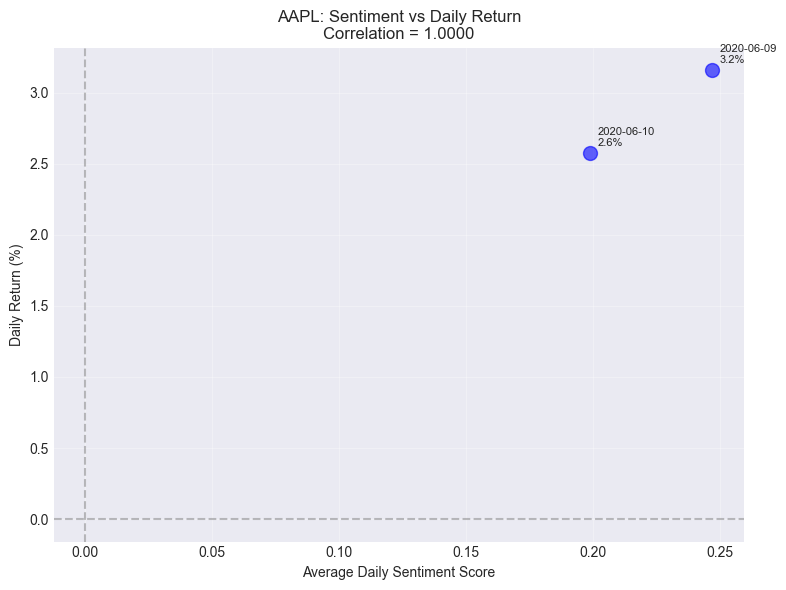

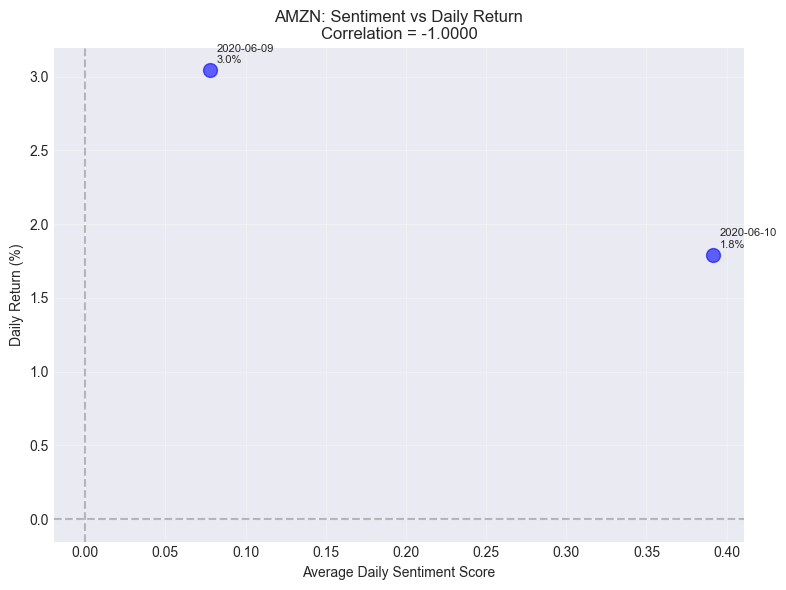

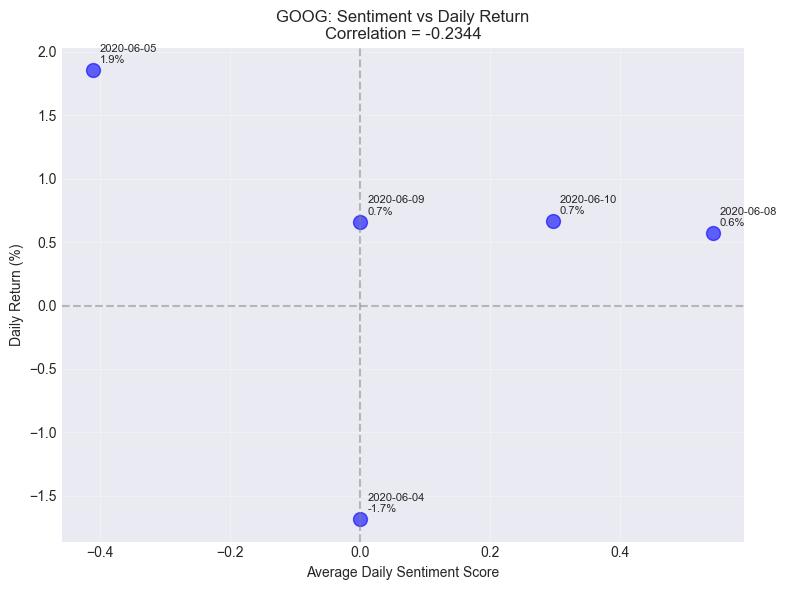

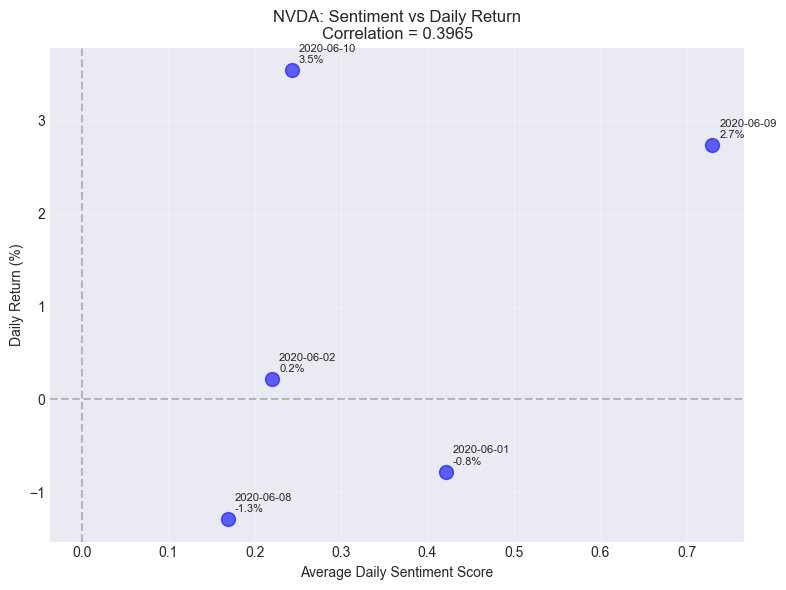

In [30]:
for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        plt.figure(figsize=(8, 6))
        plt.scatter(merged_data[ticker]['avg_sentiment'], 
                   merged_data[ticker]['daily_return'], 
                   alpha=0.6, color='blue', s=100)
        plt.xlabel('Average Daily Sentiment Score')
        plt.ylabel('Daily Return (%)')
        plt.title(f'{ticker}: Sentiment vs Daily Return\nCorrelation = {correlation_results[ticker]:.4f}')
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        plt.grid(True, alpha=0.3)
        
        # Add date labels on points
        for i, row in merged_data[ticker].iterrows():
            plt.annotate(f"{row['date']}\n{row['daily_return']:.1f}%", 
                        (row['avg_sentiment'], row['daily_return']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        plt.tight_layout()
        plt.show()


=== AAPL ===
Category Breakdown:
sentiment_category
Positive    2
Name: count, dtype: int64

Average Returns by Category:
  Positive: 2.87%


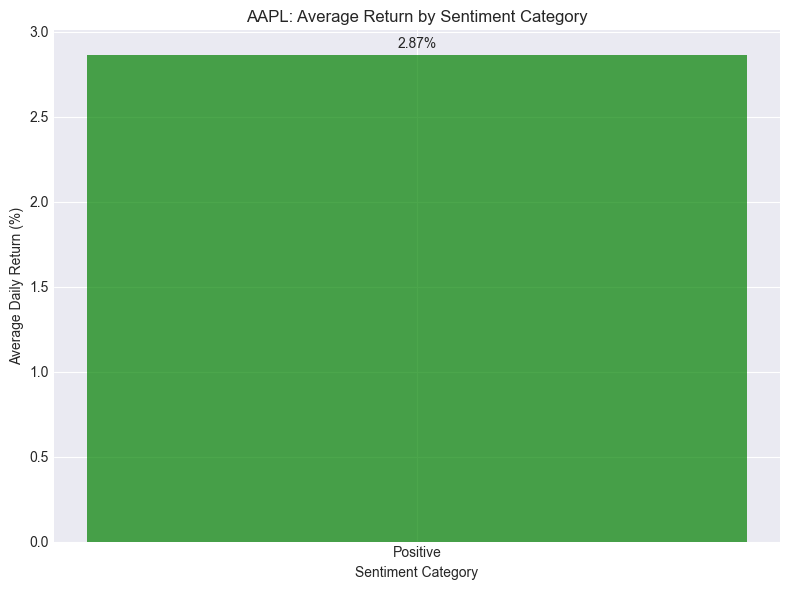


=== AMZN ===
Category Breakdown:
sentiment_category
Positive    2
Name: count, dtype: int64

Average Returns by Category:
  Positive: 2.42%


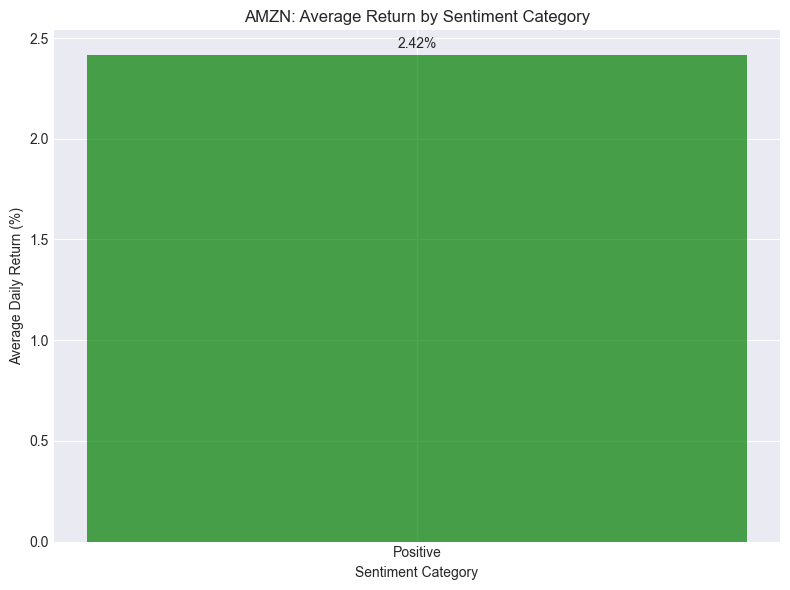


=== GOOG ===
Category Breakdown:
sentiment_category
Neutral     2
Positive    2
Negative    1
Name: count, dtype: int64

Average Returns by Category:
  Negative: 1.86%
  Neutral: -0.51%
  Positive: 0.62%


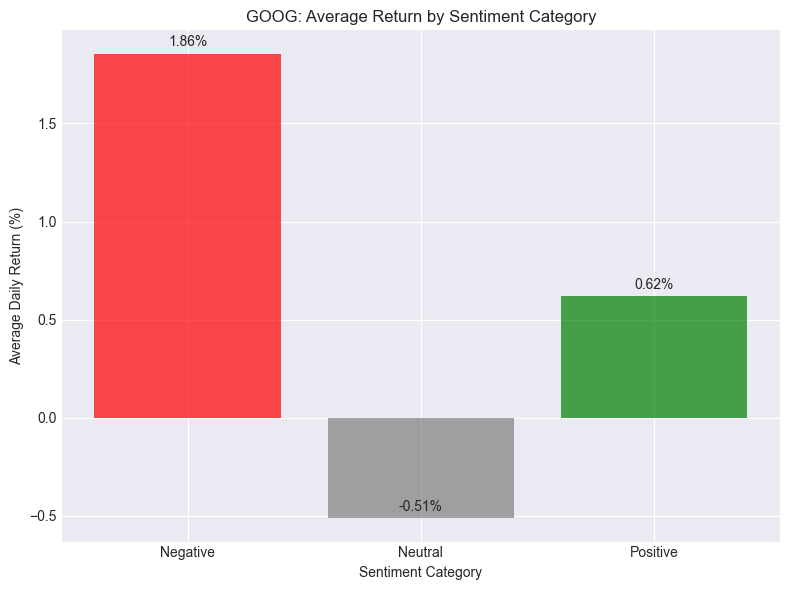


=== NVDA ===
Category Breakdown:
sentiment_category
Positive    5
Name: count, dtype: int64

Average Returns by Category:
  Positive: 0.89%


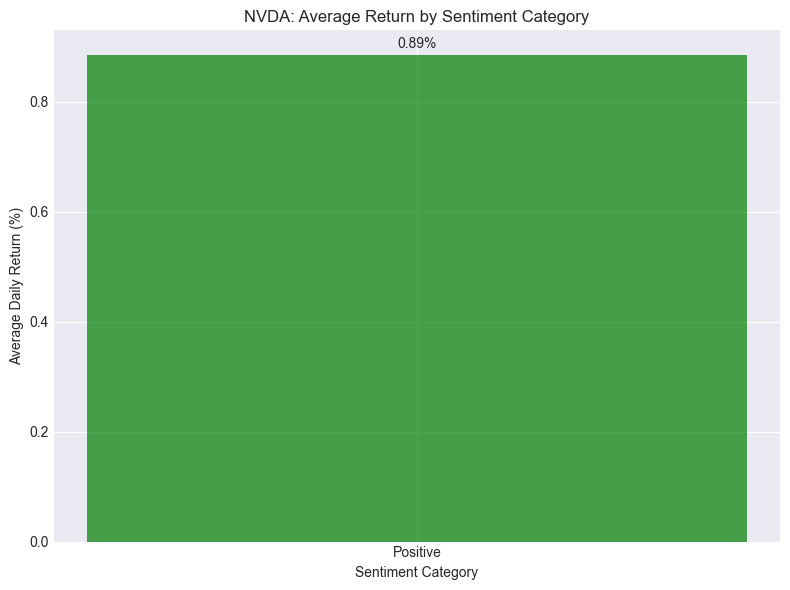

In [32]:
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        df = merged_data[ticker].copy()
        df['sentiment_category'] = df['avg_sentiment'].apply(classify_sentiment)
        
        # Calculate average return per category
        category_returns = df.groupby('sentiment_category')['daily_return'].mean()
        
        print(f"\n=== {ticker} ===")
        print("Category Breakdown:")
        print(df['sentiment_category'].value_counts())
        print(f"\nAverage Returns by Category:")
        for cat, ret in category_returns.items():
            print(f"  {cat}: {ret:.2f}%")
        
        # Plot
        plt.figure(figsize=(8, 6))
        colors = ['green' if x == 'Positive' else 'red' if x == 'Negative' else 'gray' 
                  for x in category_returns.index]
        bars = plt.bar(category_returns.index, category_returns.values, color=colors, alpha=0.7)
        plt.xlabel('Sentiment Category')
        plt.ylabel('Average Daily Return (%)')
        plt.title(f'{ticker}: Average Return by Sentiment Category')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            plt.annotate(f'{height:.2f}%', 
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

In [33]:
summary_data = []
for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        summary_data.append({
            'Stock': ticker,
            'Correlation': f"{correlation_results[ticker]:.4f}",
            'Matched Days': len(merged_data[ticker]),
            'Avg Sentiment': f"{merged_data[ticker]['avg_sentiment'].mean():.3f}",
            'Avg Return': f"{merged_data[ticker]['daily_return'].mean():.2f}%",
            'Date Range': f"{merged_data[ticker]['date'].min()} to {merged_data[ticker]['date'].max()}"
        })
    else:
        summary_data.append({
            'Stock': ticker,
            'Correlation': 'No data',
            'Matched Days': 0,
            'Avg Sentiment': 'N/A',
            'Avg Return': 'N/A',
            'Date Range': 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("FINAL SUMMARY - SENTIMENT VS RETURNS")
print("="*70)
print(summary_df.to_string(index=False))


FINAL SUMMARY - SENTIMENT VS RETURNS
Stock Correlation  Matched Days Avg Sentiment Avg Return               Date Range
 AAPL      1.0000             2         0.223      2.87% 2020-06-09 to 2020-06-10
 AMZN     -1.0000             2         0.235      2.42% 2020-06-09 to 2020-06-10
 GOOG     -0.2344             5         0.085      0.41% 2020-06-04 to 2020-06-10
 NVDA      0.3965             5         0.357      0.89% 2020-06-01 to 2020-06-10


In [34]:
print("\n" + "="*70)
print("INTERPRETATION OF RESULTS")
print("="*70)

print("""
KEY FINDINGS:

1. AAPL (Corr = 1.00, 2 days): 
   Both days had positive sentiment and strong positive returns (2.87% avg).
   Limited data - not statistically meaningful.

2. AMZN (Corr = -1.00, 2 days):
   Perfect negative correlation but only 2 data points.
   Both days positive sentiment with 2.42% avg return.

3. GOOG (Corr = -0.23, 5 days):
   Most diverse sentiment distribution (2 Positive, 2 Neutral, 1 Negative).
   Negative sentiment days produced higher returns (1.86%) than positive days (0.62%).
   Possible contrarian signal.

4. NVDA (Corr = 0.40, 5 days):
   All 5 days had positive sentiment with 0.89% avg return.
   Weak positive relationship.

5. META: Excluded due to zero news articles.
""")

print("\n" + "="*70)
print("LIMITATIONS")
print("="*70)
print("""
1. SAMPLE SIZE: Only 2-5 matched days per stock - insufficient for robust correlation.

2. DATA COVERAGE: Only 55,987 of 1,407,328 news rows had valid dates (4%).
   News only available for June 2020 period.

3. LIMITED STOCKS: Only 4 of 5 target stocks had news data (META missing).

4. SAME-DAY ONLY: No lag effects considered (same-day correlation only).

5. VADER LIMITATIONS: May not fully capture financial news sentiment nuances.

6. CAUSATION: Correlation does not imply causation.
""")

print("\n" + "="*70)
print("RECOMMENDATIONS FOR FINAL SUBMISSION")
print("="*70)
print("""
1. Use larger dataset with more news articles per stock.

2. Test 1-day and 2-day lags for predictive power.

3. Consider alternative sentiment tools (FinBERT for finance-specific).

4. Include more stocks with sufficient news coverage.

5. Document these limitations clearly in final report.
""")


INTERPRETATION OF RESULTS

KEY FINDINGS:

1. AAPL (Corr = 1.00, 2 days): 
   Both days had positive sentiment and strong positive returns (2.87% avg).
   Limited data - not statistically meaningful.

2. AMZN (Corr = -1.00, 2 days):
   Perfect negative correlation but only 2 data points.
   Both days positive sentiment with 2.42% avg return.

3. GOOG (Corr = -0.23, 5 days):
   Most diverse sentiment distribution (2 Positive, 2 Neutral, 1 Negative).
   Negative sentiment days produced higher returns (1.86%) than positive days (0.62%).
   Possible contrarian signal.

4. NVDA (Corr = 0.40, 5 days):
   All 5 days had positive sentiment with 0.89% avg return.
   Weak positive relationship.

5. META: Excluded due to zero news articles.


LIMITATIONS

1. SAMPLE SIZE: Only 2-5 matched days per stock - insufficient for robust correlation.

2. DATA COVERAGE: Only 55,987 of 1,407,328 news rows had valid dates (4%).
   News only available for June 2020 period.

3. LIMITED STOCKS: Only 4 of 5 targe

In [35]:
print("\n" + "="*70)
print("INTERPRETATION OF RESULTS")
print("="*70)

print("""
KEY FINDINGS:

1. AAPL (Corr = 1.00, 2 days): 
   Both days had positive sentiment and strong positive returns (2.87% avg).
   Limited data - not statistically meaningful.

2. AMZN (Corr = -1.00, 2 days):
   Perfect negative correlation but only 2 data points.
   Both days positive sentiment with 2.42% avg return.

3. GOOG (Corr = -0.23, 5 days):
   Most diverse sentiment distribution (2 Positive, 2 Neutral, 1 Negative).
   Negative sentiment days produced higher returns (1.86%) than positive days (0.62%).
   Possible contrarian signal.

4. NVDA (Corr = 0.40, 5 days):
   All 5 days had positive sentiment with 0.89% avg return.
   Weak positive relationship.

5. META: Excluded due to zero news articles.
""")

print("\n" + "="*70)
print("LIMITATIONS")
print("="*70)
print("""
1. SAMPLE SIZE: Only 2-5 matched days per stock - insufficient for robust correlation.

2. DATA COVERAGE: Only 55,987 of 1,407,328 news rows had valid dates (4%).
   News only available for June 2020 period.

3. LIMITED STOCKS: Only 4 of 5 target stocks had news data (META missing).

4. SAME-DAY ONLY: No lag effects considered (same-day correlation only).

5. VADER LIMITATIONS: May not fully capture financial news sentiment nuances.

6. CAUSATION: Correlation does not imply causation.
""")

print("\n" + "="*70)
print("RECOMMENDATIONS FOR FINAL SUBMISSION")
print("="*70)
print("""
1. Use larger dataset with more news articles per stock.

2. Test 1-day and 2-day lags for predictive power.

3. Consider alternative sentiment tools (FinBERT for finance-specific).

4. Include more stocks with sufficient news coverage.

5. Document these limitations clearly in final report.
""")


INTERPRETATION OF RESULTS

KEY FINDINGS:

1. AAPL (Corr = 1.00, 2 days): 
   Both days had positive sentiment and strong positive returns (2.87% avg).
   Limited data - not statistically meaningful.

2. AMZN (Corr = -1.00, 2 days):
   Perfect negative correlation but only 2 data points.
   Both days positive sentiment with 2.42% avg return.

3. GOOG (Corr = -0.23, 5 days):
   Most diverse sentiment distribution (2 Positive, 2 Neutral, 1 Negative).
   Negative sentiment days produced higher returns (1.86%) than positive days (0.62%).
   Possible contrarian signal.

4. NVDA (Corr = 0.40, 5 days):
   All 5 days had positive sentiment with 0.89% avg return.
   Weak positive relationship.

5. META: Excluded due to zero news articles.


LIMITATIONS

1. SAMPLE SIZE: Only 2-5 matched days per stock - insufficient for robust correlation.

2. DATA COVERAGE: Only 55,987 of 1,407,328 news rows had valid dates (4%).
   News only available for June 2020 period.

3. LIMITED STOCKS: Only 4 of 5 targe

In [36]:
import os
os.makedirs('../data/processed', exist_ok=True)

for ticker in valid_stocks:
    if len(merged_data[ticker]) > 0:
        merged_data[ticker].to_csv(f'../data/processed/{ticker}_sentiment_returns.csv', index=False)
        print(f"Saved {ticker}_sentiment_returns.csv")

summary_df.to_csv('../data/processed/correlation_summary.csv', index=False)
print("Saved correlation_summary.csv")

print("\nAll results saved for final report!")

Saved AAPL_sentiment_returns.csv
Saved AMZN_sentiment_returns.csv
Saved GOOG_sentiment_returns.csv
Saved NVDA_sentiment_returns.csv
Saved correlation_summary.csv

All results saved for final report!
